# Découverte Sentinel-2 autour de Libreville

**Gabon GeoAI Lab - Observer · Comprendre · Prédire · Simuler**

Objectif : rechercher des produits et comparer leurs métadonnées. Aucun téléchargement d’image, aucune authentification, aucune clé ni écriture de données.

Dans VS Code, installer les extensions Python et Jupyter, puis choisir le noyau Python de `.venv` (3.10.11 ou 3.12). Depuis la racine du dépôt :

```bash
python -m pip install -r requirements-dev.txt
```

Exécuter les cellules dans l’ordre. Une connexion Internet est nécessaire.


## 1. Comprendre le catalogue

STAC (SpatioTemporal Asset Catalog) décrit des données associées à un lieu et à une date. Un catalogue contient des **collections** ; chaque produit est un **Item**. Les **assets** désignent les fichiers associés, que nous ne consultons ni ne téléchargeons ici.

Sentinel-2 **Level-2A (L2A)** fournit notamment une réflectance de surface après correction atmosphérique. Un produit contient plusieurs bandes et résolutions ; ce notebook n’effectue aucun traitement raster.

Sources officielles : [documentation STAC CDSE](https://documentation.dataspace.copernicus.eu/APIs/STAC.html), [catalogue public](https://stac.dataspace.copernicus.eu/v1/).


In [1]:
from datetime import date
from math import isfinite
from urllib.parse import urljoin, urlparse

import requests

STAC_URL = "https://stac.dataspace.copernicus.eu/v1/"
COLLECTION_ID = "sentinel-2-l2a"
TIMEOUT_SECONDS = 40


## 2. Définir la zone pilote et la période

Une **bounding box** est un rectangle : `[longitude minimale, latitude minimale, longitude maximale, latitude maximale]`, soit ouest, sud, est, nord. Les coordonnées sont en degrés dans le référentiel géographique **WGS84**, avec la longitude en premier.

Notre rectangle va de 9,25° à 9,65° Est et de 0,20° à 0,65° Nord. Il couvre Libreville et ses environs, avec une partie côtière et maritime. C’est une zone expérimentale, pas une limite administrative.

Les produits recherchés **intersectent** ce rectangle ; cela ne garantit pas qu’un seul produit le couvre entièrement. Modifier les paramètres ci-dessous, puis réexécuter les cellules suivantes.

Le seuil nuageux sera appliqué localement aux métadonnées. La période est exprimée en UTC ; la date de fin comprend toute la journée.


In [2]:
LIBREVILLE_BBOX = [9.25, 0.20, 9.65, 0.65]
START_DATE = "2025-01-01"
END_DATE = "2025-01-31"
MAX_CLOUD_COVER = 40.0  # Pourcentage entre 0 et 100.
TOP_N = 10
PAGE_SIZE = 100
MAX_PAGES = 10  # Limite pédagogique pour éviter une recherche illimitée.


In [3]:
west, south, east, north = LIBREVILLE_BBOX
if not (-180 <= west < east <= 180 and -90 <= south < north <= 90):
    raise ValueError("Bounding box invalide : vérifier longitude et latitude.")
if date.fromisoformat(START_DATE) > date.fromisoformat(END_DATE):
    raise ValueError("La date de début doit précéder la date de fin.")
if not 0 <= MAX_CLOUD_COVER <= 100:
    raise ValueError("Le seuil nuageux doit être compris entre 0 et 100.")
if TOP_N < 1 or PAGE_SIZE < 1 or MAX_PAGES < 1:
    raise ValueError("Les limites doivent être positives.")

search_period = f"{START_DATE}T00:00:00Z/{END_DATE}T23:59:59.999Z"
print("Zone WGS84 :", LIBREVILLE_BBOX)
print("Période UTC :", search_period)


Zone WGS84 : [9.25, 0.2, 9.65, 0.65]
Période UTC : 2025-01-01T00:00:00Z/2025-01-31T23:59:59.999Z


## 3. Vérifier la collection publique

Une requête HTTP GET lit un document JSON. `raise_for_status()` rend explicites les erreurs du serveur ; le délai limite l’attente. Aucune information d’identification n’est fournie. En cas d’échec réseau, corriger la connexion puis relancer la cellule.


In [4]:
# Utilise le magasin de certificats du système d'exploitation.
# Utile notamment sur les postes d'entreprise utilisant leurs propres
# autorités de certification pour les connexions HTTPS.
import truststore

truststore.inject_into_ssl()

In [5]:
response = requests.get(
    f"{STAC_URL}collections/{COLLECTION_ID}", timeout=TIMEOUT_SECONDS
)
response.raise_for_status()
collection = response.json()
if collection.get("id") != COLLECTION_ID:
    raise ValueError("La collection attendue n’a pas été retournée.")
print("Collection :", collection["id"])
print("Titre :", collection.get("title", "Non renseigné"))


Collection : sentinel-2-l2a
Titre : Sentinel-2 Level-2A


## 4. Rechercher les métadonnées

`collections`, `bbox` et `datetime` limitent la recherche. `limit` fixe la taille demandée d’une page. Lorsqu’un lien STAC `next` est présent, nous suivons les pages suivantes jusqu’à la limite choisie.

Seules les métadonnées JSON du catalogue sont lues. Aucun lien d’asset n’est ouvert. Le tri final porte sur les résultats récupérés ; une recherche interrompue ou un catalogue partiel ne donne pas un classement exhaustif.


In [6]:
search_params = {
    "collections": COLLECTION_ID,
    "bbox": ",".join(str(value) for value in LIBREVILLE_BBOX),
    "datetime": search_period,
    "limit": PAGE_SIZE,
}
items_by_id = {}
next_url = f"{STAC_URL}search"
params = search_params
search_truncated = False

for page_number in range(1, MAX_PAGES + 1):
    response = requests.get(next_url, params=params, timeout=TIMEOUT_SECONDS)
    response.raise_for_status()
    page = response.json()
    if page.get("type") != "FeatureCollection":
        raise ValueError("La réponse n’est pas une collection de résultats STAC.")
    features = page.get("features", [])
    for item in features:
        items_by_id[item["id"]] = item
    print(f"Page {page_number} : {len(features)} produit(s)")

    next_link = next(
        (link for link in page.get("links", []) if link.get("rel") == "next"), None
    )
    if next_link is None:
        if len(features) >= PAGE_SIZE:
            print("Attention : page pleine sans lien suivant ; exhaustivité à vérifier.")
        break
    if page_number == MAX_PAGES:
        search_truncated = True
        break
    next_url = urljoin(response.url, next_link["href"])
    # Rester sur le catalogue public et sur une pagination GET.
    if (urlparse(next_url).scheme != "https"
            or urlparse(next_url).netloc != urlparse(STAC_URL).netloc
            or next_link.get("method", "GET").upper() != "GET"):
        raise ValueError("Lien de pagination non pris en charge : examiner les métadonnées.")
    params = None  # Le lien suivant porte ses propres paramètres.

items = list(items_by_id.values())
print(f"Total : {len(items)} produit(s) distinct(s)")
if search_truncated:
    print("Recherche limitée : réduire la période ou augmenter MAX_PAGES avant comparaison.")


Page 1 : 5 produit(s)
Total : 5 produit(s) distinct(s)


## 5. Lire et afficher les résultats

`datetime` indique la date d’acquisition et `eo:cloud_cover` la couverture nuageuse en pourcentage : une valeur faible est généralement préférable pour observer la surface.

Cette valeur concerne **l’ensemble du produit**, pas uniquement notre rectangle. Elle ne suffit pas à déterminer la qualité locale : ombres, brume, couverture spatiale et masques de qualité devront être examinés dans une phase ultérieure.

Les valeurs absentes ou invalides sont affichées comme « Non renseignée » et exclues des candidates. Aucune valeur manquante n’est assimilée à 0 %.


In [7]:
def read_cloud_cover(value):
    """Retourne un pourcentage valide ou None si la métadonnée manque."""
    if value is None or isinstance(value, bool):
        return None
    try:
        cloud_cover = float(value)
    except (TypeError, ValueError):
        return None
    return cloud_cover if isfinite(cloud_cover) and 0 <= cloud_cover <= 100 else None


records = []
for item in items:
    properties = item.get("properties", {})
    records.append({
        "id": item["id"],
        "acquired_at": properties.get("datetime"),
        "cloud_cover": read_cloud_cover(properties.get("eo:cloud_cover")),
    })


In [8]:
def display_records(rows):
    """Affiche un tableau texte sans dépendance supplémentaire."""
    if not rows:
        print("Aucun résultat pour ces paramètres.")
        return
    print(f"{'ID':<75} | {'Acquisition UTC':<27} | Nuages (%)")
    print("-" * 120)
    for row in rows:
        cloud = row["cloud_cover"]
        cloud_label = f"{cloud:.2f}" if cloud is not None else "Non renseignée"
        acquired_at = row["acquired_at"] or "Non renseignée"
        print(f"{row['id']:<75} | {acquired_at:<27} | {cloud_label}")


display_records(records)


ID                                                                          | Acquisition UTC             | Nuages (%)
------------------------------------------------------------------------------------------------------------------------
S2B_MSIL2A_20250125T093159_N0511_R136_T32NNF_20250125T115658                | 2025-01-25T09:31:59.024Z    | 36.98
S2A_MSIL2A_20250120T093321_N0511_R136_T32NNF_20250120T125148                | 2025-01-20T09:33:21.024Z    | 82.64
S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528                | 2025-01-15T09:32:39.024Z    | 36.14
S2A_MSIL2A_20250110T093351_N0511_R136_T32NNF_20250110T135958                | 2025-01-10T09:33:51.024Z    | 99.41
S2B_MSIL2A_20250105T093309_N0511_R136_T32NNF_20250105T120229                | 2025-01-05T09:33:09.024Z    | 99.98


## 6. Classer les meilleures candidates

Nous conservons les produits dont la couverture nuageuse est renseignée et inférieure ou égale au seuil. Le classement privilégie la couverture nuageuse croissante, puis la date croissante et l’ID pour départager les égalités.

Il s’agit d’un classement des **produits** : plusieurs produits peuvent appartenir à une même acquisition. Il ne sélectionne pas encore une mosaïque couvrant toute la zone.


In [9]:
candidates = [
    row for row in records
    if row["cloud_cover"] is not None and row["cloud_cover"] <= MAX_CLOUD_COVER
]
ranked_candidates = sorted(
    candidates,
    key=lambda row: (row["cloud_cover"], row["acquired_at"] or "", row["id"]),
)
missing_cloud_count = sum(row["cloud_cover"] is None for row in records)
print(f"Seuil : {MAX_CLOUD_COVER:.1f} % ; candidates : {len(ranked_candidates)}")
print(f"Couverture nuageuse absente ou invalide : {missing_cloud_count}")
display_records(ranked_candidates[:TOP_N])


Seuil : 40.0 % ; candidates : 2
Couverture nuageuse absente ou invalide : 0
ID                                                                          | Acquisition UTC             | Nuages (%)
------------------------------------------------------------------------------------------------------------------------
S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528                | 2025-01-15T09:32:39.024Z    | 36.14
S2B_MSIL2A_20250125T093159_N0511_R136_T32NNF_20250125T115658                | 2025-01-25T09:31:59.024Z    | 36.98


## Pour apprendre et vérifier

1. Réexécuter toutes les cellules avec les paramètres par défaut et lire les trois colonnes.
2. Réduire le seuil nuageux à 20 %, puis relancer le classement : le nombre de candidates ne doit pas augmenter.
3. Changer le mois et relancer toutes les cellules : comparer la disponibilité et les nuages.
4. Vérifier que les candidates respectent le seuil et que la couverture nuageuse est croissante.
5. Si aucun produit ne passe le seuil, élargir la période ou relever le seuil explicitement.

Avant de partager le notebook, effacer ses sorties. Aucun fichier d’image, donnée raster ou secret ne doit être ajouté au dépôt.


In [10]:
best_candidate_id = ranked_candidates[0]["id"] if ranked_candidates else None

if best_candidate_id is None:
    print("Aucun candidat disponible.")
else:
    best_item = items_by_id[best_candidate_id]

    print("Produit sélectionné :", best_candidate_id)
    print("\nAssets disponibles :")

    for asset_name, asset in best_item.get("assets", {}).items():
        print(
            asset_name,
            "|",
            asset.get("type", "type non renseigné"),
            "|",
            asset.get("title", "titre non renseigné"),
        )

Produit sélectionné : S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528

Assets disponibles :
AOT_10m | image/jp2 | Aerosol optical thickness (AOT) - 10m
AOT_20m | image/jp2 | Aerosol optical thickness (AOT) - 20m
AOT_60m | image/jp2 | Aerosol optical thickness (AOT) - 60m
B01_20m | image/jp2 | Coastal aerosol (band 1) - 20m
B01_60m | image/jp2 | Coastal aerosol (band 1) - 60m
B02_10m | image/jp2 | Blue (band 2) - 10m
B02_20m | image/jp2 | Blue (band 2) - 20m
B02_60m | image/jp2 | Blue (band 2) - 60m
B03_10m | image/jp2 | Green (band 3) - 10m
B03_20m | image/jp2 | Green (band 3) - 20m
B03_60m | image/jp2 | Green (band 3) - 60m
B04_10m | image/jp2 | Red (band 4) - 10m
B04_20m | image/jp2 | Red (band 4) - 20m
B04_60m | image/jp2 | Red (band 4) - 60m
B05_20m | image/jp2 | Red edge 1 (band 5) - 20m
B05_60m | image/jp2 | Red edge 1 (band 5) - 60m
B06_20m | image/jp2 | Red edge 2 (band 6) - 20m
B06_60m | image/jp2 | Red edge 2 (band 6) - 60m
B07_20m | image/jp2 | Red edge 3 (band 

In [11]:
if best_candidate_id is not None:
    b04_asset = best_item["assets"]["B04_10m"]

    print("Asset :", "B04_10m")
    print("Type :", b04_asset.get("type"))
    print("Titre :", b04_asset.get("title"))
    print("Adresse :", b04_asset.get("href"))

Asset : B04_10m
Type : image/jp2
Titre : Red (band 4) - 10m
Adresse : s3://eodata/Sentinel-2/MSI/L2A/2025/01/15/S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528.SAFE/GRANULE/L2A_T32NNF_A041060_20250115T095009/IMG_DATA/R10m/T32NNF_20250115T093239_B04_10m.jp2


In [12]:
import os
from pathlib import Path

from dotenv import load_dotenv

project_root = Path.cwd().parent
load_dotenv(project_root / ".env")

s3_access_key = os.getenv("CDSE_S3_ACCESS_KEY")
s3_secret_key = os.getenv("CDSE_S3_SECRET_KEY")

if not s3_access_key or not s3_secret_key:
    raise RuntimeError("Credentials S3 Copernicus introuvables.")

print("Credentials S3 chargés :", bool(s3_access_key and s3_secret_key))

Credentials S3 chargés : True


In [13]:
import boto3

s3 = boto3.client(
    "s3",
    endpoint_url="https://eodata.dataspace.copernicus.eu",
    aws_access_key_id=s3_access_key,
    aws_secret_access_key=s3_secret_key,
    region_name="default",
)

bucket_name = "eodata"

b04_s3_uri = b04_asset["href"]
b04_key = b04_s3_uri.removeprefix("s3://eodata/")

print("Bucket :", bucket_name)
print("Fichier :", b04_key.split("/")[-1])

Bucket : eodata
Fichier : T32NNF_20250115T093239_B04_10m.jp2


In [14]:
metadata = s3.head_object(
    Bucket=bucket_name,
    Key=b04_key,
)

size_mb = metadata["ContentLength"] / (1024 * 1024)

print("Accès S3 : OK")
print(f"Taille du fichier B04 : {size_mb:.1f} Mo")
print("Type :", metadata.get("ContentType", "Non renseigné"))

Accès S3 : OK
Taille du fichier B04 : 99.2 Mo
Type : binary/octet-stream


## 6. Lecture du raster Sentinel-2

Objectif : ouvrir la bande B04 avec Rasterio et comprendre sa structure géospatiale avant toute analyse.

In [15]:
import rasterio

In [16]:
import os

os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_ACCESS_KEY_ID"] = s3_access_key
os.environ["AWS_SECRET_ACCESS_KEY"] = s3_secret_key
os.environ["AWS_HTTPS"] = "YES"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

In [17]:
from pathlib import Path

raw_dir = Path("../data/raw/sentinel2")
raw_dir.mkdir(parents=True, exist_ok=True)

b04_local_path = raw_dir / b04_key.split("/")[-1]

print(b04_local_path)

..\data\raw\sentinel2\T32NNF_20250115T093239_B04_10m.jp2


In [18]:
if not b04_local_path.exists():
    print("Téléchargement de B04...")
    
    s3.download_file(
        bucket_name,
        b04_key,
        str(b04_local_path),
    )
    
    print("Téléchargement terminé.")
else:
    print("B04 existe déjà localement.")

B04 existe déjà localement.


In [19]:
with rasterio.open(b04_local_path) as src:
    print("Driver :", src.driver)
    print("Largeur :", src.width)
    print("Hauteur :", src.height)
    print("Nombre de bandes :", src.count)
    print("Type des pixels :", src.dtypes)
    print("CRS :", src.crs)
    print("Résolution :", src.res)
    print("Emprise :", src.bounds)

Driver : JP2OpenJPEG
Largeur : 10980
Hauteur : 10980
Nombre de bandes : 1
Type des pixels : ('uint16',)
CRS : EPSG:32632
Résolution : (10.0, 10.0)
Emprise : BoundingBox(left=499980.0, bottom=-9780.0, right=609780.0, top=100020.0)


In [20]:
with rasterio.open(b04_local_path) as src:
    b04_preview = src.read(
        1,
        out_shape=(1000, 1000),
    )

print("Dimensions de l'aperçu :", b04_preview.shape)

Dimensions de l'aperçu : (1000, 1000)


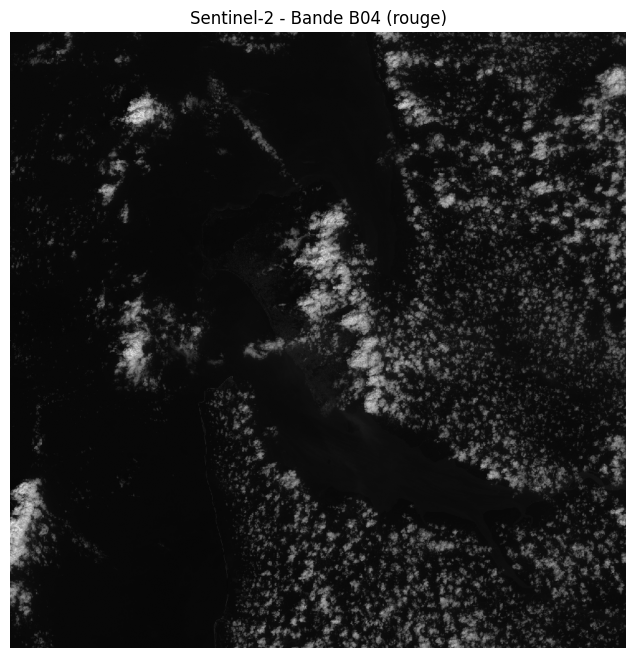

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(b04_preview, cmap="gray")
plt.title("Sentinel-2 - Bande B04 (rouge)")
plt.axis("off")
plt.show()

In [22]:
print("Minimum :", b04_preview.min())
print("Maximum :", b04_preview.max())
print("Moyenne :", b04_preview.mean())
print("Type :", b04_preview.dtype)

Minimum : 777
Maximum : 19473
Moyenne : 2596.369154
Type : uint16


In [25]:
for band in ["B02_10m", "B03_10m", "B04_10m"]:
    asset = best_item["assets"].get(band)
    print(band, "→", asset["href"] if asset else "Introuvable")

B02_10m → s3://eodata/Sentinel-2/MSI/L2A/2025/01/15/S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528.SAFE/GRANULE/L2A_T32NNF_A041060_20250115T095009/IMG_DATA/R10m/T32NNF_20250115T093239_B02_10m.jp2
B03_10m → s3://eodata/Sentinel-2/MSI/L2A/2025/01/15/S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528.SAFE/GRANULE/L2A_T32NNF_A041060_20250115T095009/IMG_DATA/R10m/T32NNF_20250115T093239_B03_10m.jp2
B04_10m → s3://eodata/Sentinel-2/MSI/L2A/2025/01/15/S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528.SAFE/GRANULE/L2A_T32NNF_A041060_20250115T095009/IMG_DATA/R10m/T32NNF_20250115T093239_B04_10m.jp2


In [26]:
def download_band(band_name):
    asset = best_item["assets"].get(band_name)

    if asset is None:
        raise ValueError(f"Bande introuvable : {band_name}")

    s3_uri = asset["href"]
    s3_key = s3_uri.removeprefix("s3://eodata/")
    local_path = raw_dir / s3_key.split("/")[-1]

    if not local_path.exists():
        print(f"Téléchargement de {band_name}...")
        s3.download_file(
            bucket_name,
            s3_key,
            str(local_path),
        )
        print(f"{band_name} téléchargée.")
    else:
        print(f"{band_name} existe déjà.")

    return local_path

In [27]:
b02_local_path = download_band("B02_10m")
b03_local_path = download_band("B03_10m")
b04_local_path = download_band("B04_10m")

Téléchargement de B02_10m...


c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate

B02_10m téléchargée.
Téléchargement de B03_10m...


c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate

B03_10m téléchargée.
B04_10m existe déjà.


In [28]:
with rasterio.open(b02_local_path) as src:
    b02_preview = src.read(1, out_shape=(1000, 1000))

with rasterio.open(b03_local_path) as src:
    b03_preview = src.read(1, out_shape=(1000, 1000))

with rasterio.open(b04_local_path) as src:
    b04_preview = src.read(1, out_shape=(1000, 1000))

In [29]:
print("B02 :", b02_preview.shape)
print("B03 :", b03_preview.shape)
print("B04 :", b04_preview.shape)

B02 : (1000, 1000)
B03 : (1000, 1000)
B04 : (1000, 1000)


In [30]:
import numpy as np

In [31]:
rgb_preview = np.dstack((b04_preview, b03_preview, b02_preview))

In [32]:
print(rgb_preview.shape)
print(rgb_preview[500, 300])

(1000, 1000, 3)
[4765 4801 4920]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [777..21772].


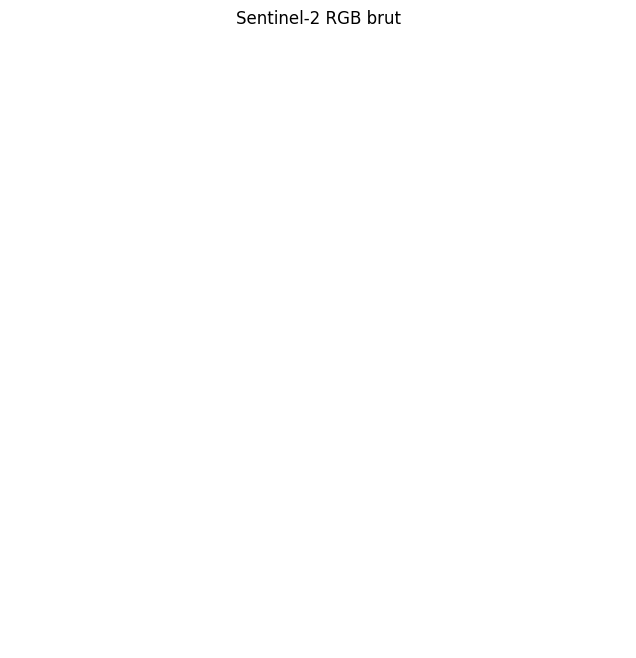

In [33]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb_preview)
plt.title("Sentinel-2 RGB brut")
plt.axis("off")
plt.show()

In [34]:
def stretch_band(band):
    p2, p98 = np.percentile(band, (2, 98))

    stretched = (band - p2) / (p98 - p2)

    return np.clip(stretched, 0, 1)

In [35]:
r = stretch_band(b04_preview)
g = stretch_band(b03_preview)
b = stretch_band(b02_preview)

rgb_stretched = np.dstack((r, g, b))

In [36]:
print("Shape :", rgb_stretched.shape)
print("Minimum :", rgb_stretched.min())
print("Maximum :", rgb_stretched.max())

Shape : (1000, 1000, 3)
Minimum : 0.0
Maximum : 1.0


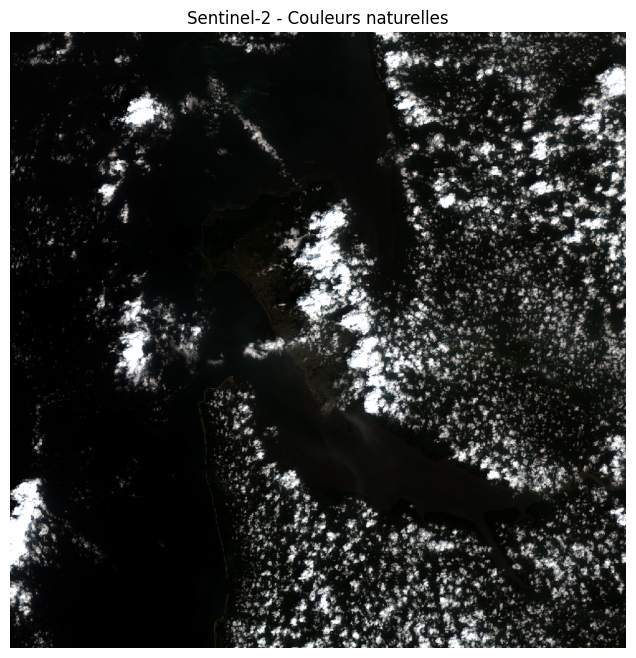

In [37]:
plt.figure(figsize=(8, 8))
plt.imshow(rgb_stretched)
plt.title("Sentinel-2 - Couleurs naturelles")
plt.axis("off")
plt.show()

In [38]:
b08_asset = best_item["assets"].get("B08_10m")

print(b08_asset["href"] if b08_asset else "B08_10m introuvable")

s3://eodata/Sentinel-2/MSI/L2A/2025/01/15/S2B_MSIL2A_20250115T093239_N0511_R136_T32NNF_20250115T120528.SAFE/GRANULE/L2A_T32NNF_A041060_20250115T095009/IMG_DATA/R10m/T32NNF_20250115T093239_B08_10m.jp2


In [39]:
b08_local_path = download_band("B08_10m")

Téléchargement de B08_10m...


c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\ext-anyandwi\OneDrive - Eramet SA\PROJETS\gabon-geoai-lab\.venv\lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'eodata.dataspace.copernicus.eu'. Adding certificate

B08_10m téléchargée.


In [40]:
with rasterio.open(b08_local_path) as src:
    b08_preview = src.read(
        1,
        out_shape=(1000, 1000),
    )

print("B08 :", b08_preview.shape)
print("Minimum :", b08_preview.min())
print("Maximum :", b08_preview.max())
print("Type :", b08_preview.dtype)

B08 : (1000, 1000)
Minimum : 563
Maximum : 18882
Type : uint16


In [42]:
nir = b08_preview.astype("float32")
red = b04_preview.astype("float32")

In [43]:
ndvi = (nir - red) / (nir + red)

print("Shape :", ndvi.shape)
print("Minimum :", ndvi.min())
print("Maximum :", ndvi.max())
print("Moyenne :", ndvi.mean())

Shape : (1000, 1000)
Minimum : -0.46085092
Maximum : 0.5900894
Moyenne : 0.08969718


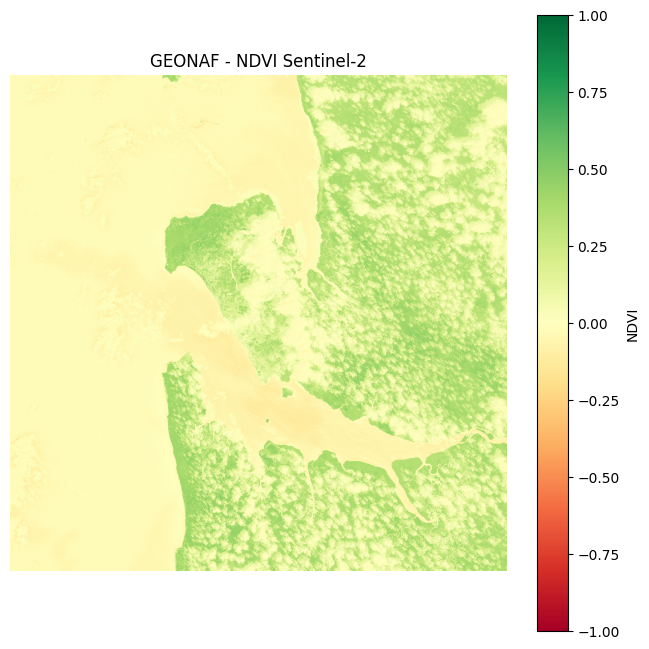

In [44]:
plt.figure(figsize=(8, 8))

plt.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDVI")
plt.title("GEONAF - NDVI Sentinel-2")
plt.axis("off")
plt.show()

In [45]:
for asset_name in best_item["assets"]:
    if "SCL" in asset_name.upper():
        print(asset_name)

SCL_20m
SCL_60m


In [46]:
scl_local_path = download_band("SCL_20m")

Téléchargement de SCL_20m...
SCL_20m téléchargée.


In [47]:
with rasterio.open(scl_local_path) as src:
    print("Dimensions :", src.shape)
    print("Résolution :", src.res)
    print("CRS :", src.crs)
    print("Type :", src.dtypes)

Dimensions : (5490, 5490)
Résolution : (20.0, 20.0)
CRS : EPSG:32632
Type : ('uint8',)


In [48]:
from rasterio.enums import Resampling

In [49]:
with rasterio.open(scl_local_path) as src:
    scl_preview = src.read(
        1,
        out_shape=(1000, 1000),
        resampling=Resampling.nearest,
    )

print("Shape :", scl_preview.shape)
print("Type :", scl_preview.dtype)
print("Classes présentes :", np.unique(scl_preview))

Shape : (1000, 1000)
Type : uint8
Classes présentes : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [50]:
with rasterio.open(scl_local_path) as src:
    scl_native = src.read(1)

print("Classes natives :", np.unique(scl_native))

Classes natives : [ 2  3  4  5  6  7  8  9 10]


In [51]:
cloud_classes = [3, 8, 9, 10]

cloud_mask_native = np.isin(
    scl_native,
    cloud_classes
)

In [52]:
print("Shape :", cloud_mask_native.shape)
print("Type :", cloud_mask_native.dtype)

cloud_percentage = cloud_mask_native.mean() * 100
print("Pixels masqués :", round(cloud_percentage, 2), "%")

Shape : (5490, 5490)
Type : bool
Pixels masqués : 36.21 %


In [53]:
with rasterio.open(scl_local_path) as src:
    scl_for_ndvi = src.read(
        1,
        out_shape=ndvi.shape,
        resampling=Resampling.nearest,
    )

cloud_mask = np.isin(
    scl_for_ndvi,
    [3, 8, 9, 10]
)

In [54]:
print("NDVI :", ndvi.shape)
print("Masque :", cloud_mask.shape)
print("Classes après rééchantillonnage :", np.unique(scl_for_ndvi))

NDVI : (1000, 1000)
Masque : (1000, 1000)
Classes après rééchantillonnage : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]


In [55]:
from rasterio.warp import reproject

In [56]:
with rasterio.open(b04_local_path) as red_src:
    red_transform = red_src.transform
    red_crs = red_src.crs
    red_width = red_src.width
    red_height = red_src.height

with rasterio.open(scl_local_path) as scl_src:
    scl_aligned = np.empty(
        (red_height, red_width),
        dtype=np.uint8
    )

    reproject(
        source=rasterio.band(scl_src, 1),
        destination=scl_aligned,
        src_transform=scl_src.transform,
        src_crs=scl_src.crs,
        dst_transform=red_transform,
        dst_crs=red_crs,
        resampling=Resampling.nearest,
    )

In [57]:
print("Shape :", scl_aligned.shape)
print("Classes :", np.unique(scl_aligned))

Shape : (10980, 10980)
Classes : [ 2  3  4  5  6  7  8  9 10]


In [58]:
with rasterio.open(b04_local_path) as src:
    red_native = src.read(1).astype("float32")

with rasterio.open(b08_local_path) as src:
    nir_native = src.read(1).astype("float32")

print("B04 :", red_native.shape)
print("B08 :", nir_native.shape)
print("SCL :", scl_aligned.shape)

B04 : (10980, 10980)
B08 : (10980, 10980)
SCL : (10980, 10980)


In [59]:
cloud_mask = np.isin(
    scl_aligned,
    [3, 8, 9, 10]
)

print("Pixels nuages/ombres :", round(cloud_mask.mean() * 100, 2), "%")

Pixels nuages/ombres : 36.21 %


In [60]:
ndvi_native = (nir_native - red_native) / (nir_native + red_native)

In [61]:
ndvi_clean = ndvi_native.copy()
ndvi_clean[cloud_mask] = np.nan

In [62]:
print("NDVI min :", np.nanmin(ndvi_clean))
print("NDVI max :", np.nanmax(ndvi_clean))
print("NDVI moyen :", np.nanmean(ndvi_clean))
print("Pixels exclus :", round(np.isnan(ndvi_clean).mean() * 100, 2), "%")

NDVI min : -0.3440476
NDVI max : 0.5775787
NDVI moyen : 0.09663078
Pixels exclus : 36.21 %


In [63]:
step = 10
ndvi_display = ndvi_clean[::step, ::step]

print("Affichage :", ndvi_display.shape)

Affichage : (1098, 1098)


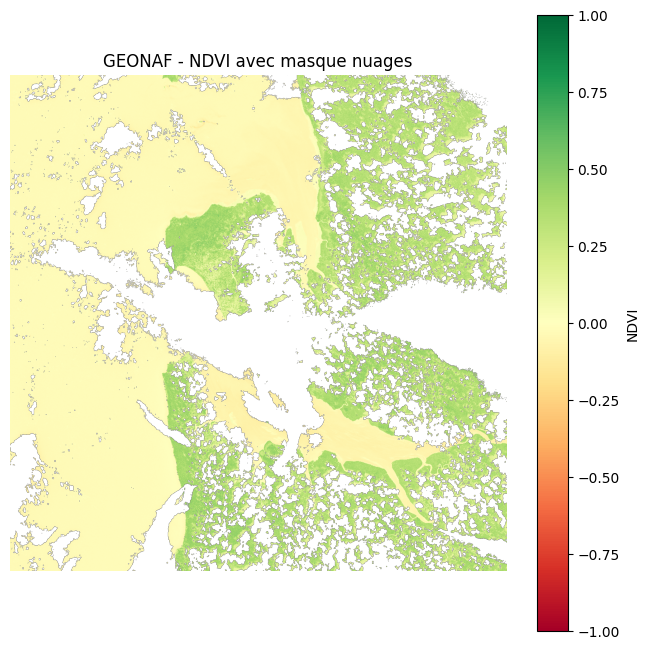

In [64]:
plt.figure(figsize=(8, 8))

plt.imshow(
    ndvi_display,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDVI")
plt.title("GEONAF - NDVI avec masque nuages")
plt.axis("off")
plt.show()